# MVP training run

Dataset: CIFAR-100 

To view runs: `aim up` in a terminal from this directory, then open localhost:43800.

In [8]:
from dataclasses import asdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from torchinfo import summary

from aim import Run

from train import train, TrainConfig, TrainJob
from eval import evaluate, plot_loss, plot_metrics

## config

In [2]:
batch_size = 128
image_size = 224
num_classes = 100

train_cfg = TrainConfig(
  epochs=2,
  lr=1e-3,
  weight_decay=1e-4,
  seed=0,
  device="cuda" if torch.cuda.is_available() else "cpu",
)

In [3]:
torch.manual_seed(train_cfg.seed)
torch.cuda.manual_seed_all(train_cfg.seed)
print(f"device: {train_cfg.device}")

device: cuda


## data

ImageNet normalization since we use an ImageNet-pretrained backbone.

In [ ]:
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

train_tf = transforms.Compose([
  transforms.RandomHorizontalFlip(),
  transforms.ToTensor(),
  transforms.Normalize(mean, std),
])
test_tf = transforms.Compose([
  transforms.ToTensor(),
  transforms.Normalize(mean, std),
])

train_set = datasets.ImageNet("./data", train=True, download=True, transform=train_tf)
test_set = datasets.ImageNet("./data", train=False, download=True, transform=test_tf)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"train: {len(train_set)}, test: {len(test_set)}")

/home/main/Development/research/multi-agent/.venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


train: 50000, test: 10000


## model

Swap this cell for the multi-agent system when ready.

In [5]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"trainable params: {n_params:,}")

trainable params: 11,227,812


In [9]:
summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 100]                  --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│

## optimizer + loss

In [ ]:
optimizer = optim.AdamW(model.parameters(), lr=train_cfg.lr, weight_decay=train_cfg.weight_decay)
criterion = nn.CrossEntropyLoss()

## aim run

Hparams logged for filtering/comparing runs later.

In [ ]:
run = Run(experiment="mvp")
run["hparams"] = {
  **asdict(train_cfg),
  "batch_size": batch_size,
  "image_size": image_size,
  "num_classes": num_classes,
  "model": "resnet18-pretrained",
}
print(f"aim run hash: {run.hash}")

aim run hash: 968eeb1c50cb4bc8bb4a23ba


## train

In [ ]:
job = TrainJob(
  model=model,
  loader=train_loader,
  optimizer=optimizer,
  criterion=criterion,
  config=train_cfg,
  run=run,
)
losses = train(job)

epoch 0 step 0 loss 4.8345
epoch 0 step 50 loss 2.1240
epoch 0 step 100 loss 1.8688
epoch 0 step 150 loss 1.7149
epoch 0 step 200 loss 1.5948
epoch 0 step 250 loss 1.6169
epoch 0 step 300 loss 1.3647
epoch 0 step 350 loss 1.0855
epoch 1 step 400 loss 0.9865
epoch 1 step 450 loss 1.0051
epoch 1 step 500 loss 0.7581
epoch 1 step 550 loss 0.8844
epoch 1 step 600 loss 0.8759
epoch 1 step 650 loss 0.9568
epoch 1 step 700 loss 0.9612
epoch 1 step 750 loss 1.2950


## loss curve

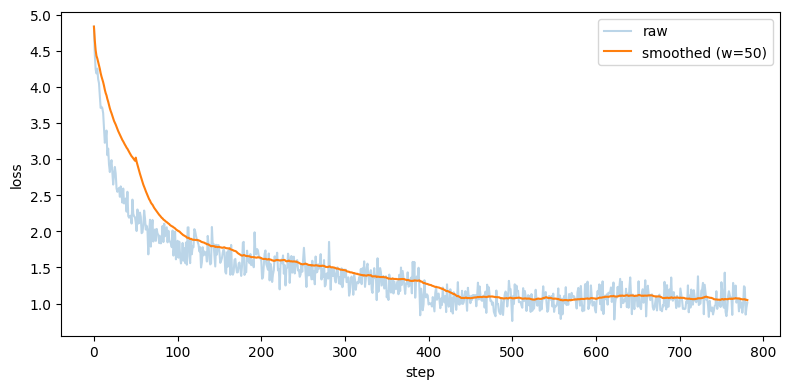

In [9]:
plot_loss(losses, smooth=50)

## evaluate on test

In [ ]:
results = evaluate(model, test_loader, device=train_cfg.device, criterion=criterion)
print(results)
for k, v in results.items():
  run.track(v, name=f"test_{k}")

{'accuracy': 0.6431, 'loss': 1.2432991264343263}


## metrics

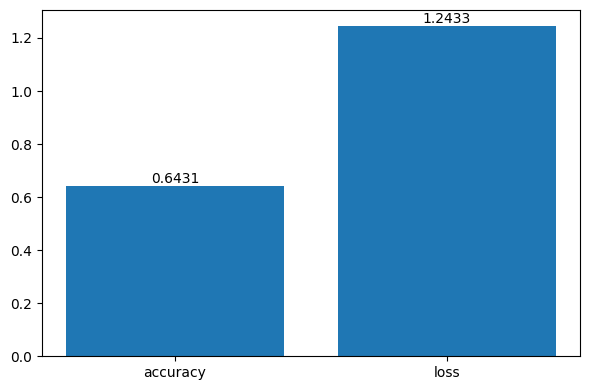

In [11]:
plot_metrics(results)

## done

In [12]:
run.close()